# Homework 02: Multi-Class Classification with Neural Networks

#### Due Date: Sunday, September 13th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

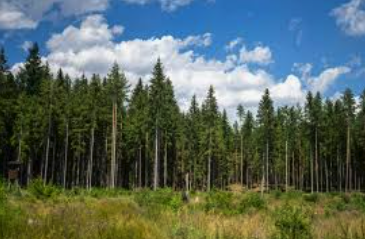

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


In [1]:
# Useful imports
#!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

I0000 00:00:1789333255.428407   17220 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789333255.738773   17220 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789333259.474708   17220 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# Load
X, y = fetch_covtype(return_X_y=True)   # y in {1..7}
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0..6 for Keras
print("Subset shape:", X_sub.shape, "Class counts:", Counter(y_sub))


Subset shape: (19229, 54) Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these three steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [4]:
 # Perform train-test split, keeping both stratified, then standardize

# Your code here
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sub,
    y_sub,
    test_size=0.2,
    random_state=random_seed,
    stratify=y_sub
)

# Fit the scaler only on the training data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train.shape = {X_train.shape}")
print(f"X_test.shape  = {X_test.shape}")
print(f"y_train.shape = {y_train.shape}")
print(f"y_test.shape  = {y_test.shape}")

print("\nTraining class counts:", Counter(y_train))
print("Test class counts:", Counter(y_test))


X_train.shape = (15383, 54)
X_test.shape  = (3846, 54)
y_train.shape = (15383,)
y_test.shape  = (3846,)

Training class counts: Counter({np.int32(5): 2198, np.int32(1): 2198, np.int32(0): 2198, np.int32(2): 2198, np.int32(6): 2197, np.int32(3): 2197, np.int32(4): 2197})
Test class counts: Counter({np.int32(3): 550, np.int32(4): 550, np.int32(6): 550, np.int32(1): 549, np.int32(0): 549, np.int32(5): 549, np.int32(2): 549})


### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



E0000 00:00:1789333260.873738   17220 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3486 - loss: 1.7953
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5548 - loss: 1.2904
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6035 - loss: 1.0397
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6261 - loss: 0.9402
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6420 - loss: 0.8861
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6596 - loss: 0.8505
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6735 - loss: 0.8240
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6825 - loss: 0.8032
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6886 - loss: 0.7860
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6926 - loss: 0.7710
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6978 - loss: 0.7576
Epoch 12/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

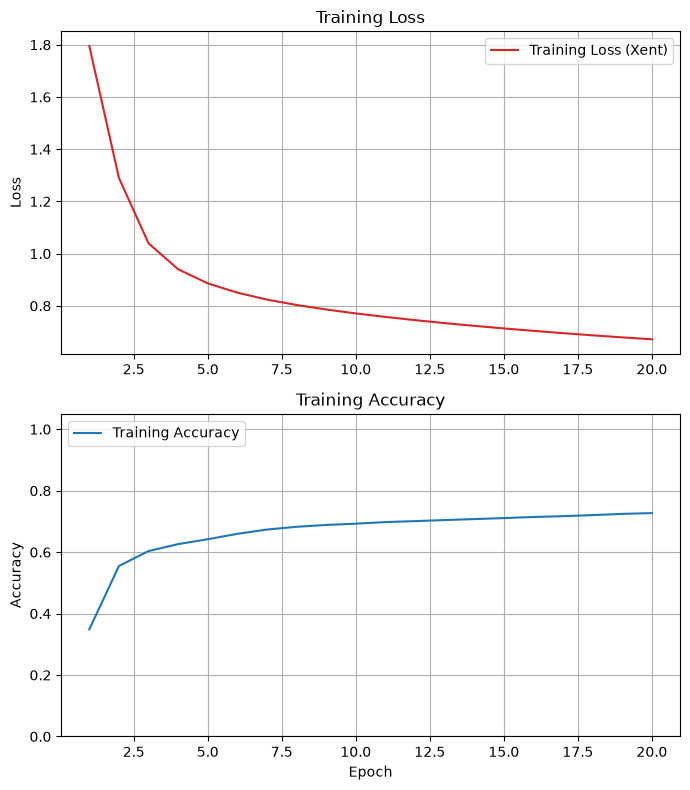

Final Training Loss:     0.6719
Final Training Accuracy: 0.7271


In [5]:
# Your code here

# Clear any previous models and reset the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(random_seed)

# Build the baseline neural network
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(7, activation="softmax")
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display the model structure
model.summary()

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Plot training loss and accuracy
plot_history(history)

In [6]:
# Set a1a to the final training accuracy at epoch 20

a1a = history.history["accuracy"][-1]             # Replace 0.0 with your answer

In [7]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.7271


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!


Training with batch size: 4


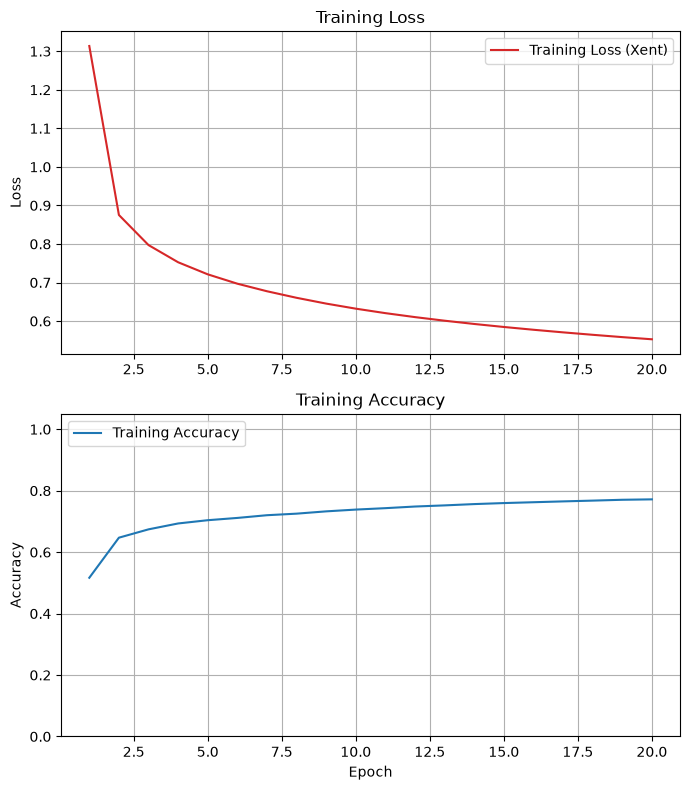

Final Training Loss:     0.5528
Final Training Accuracy: 0.7718

Training with batch size: 8


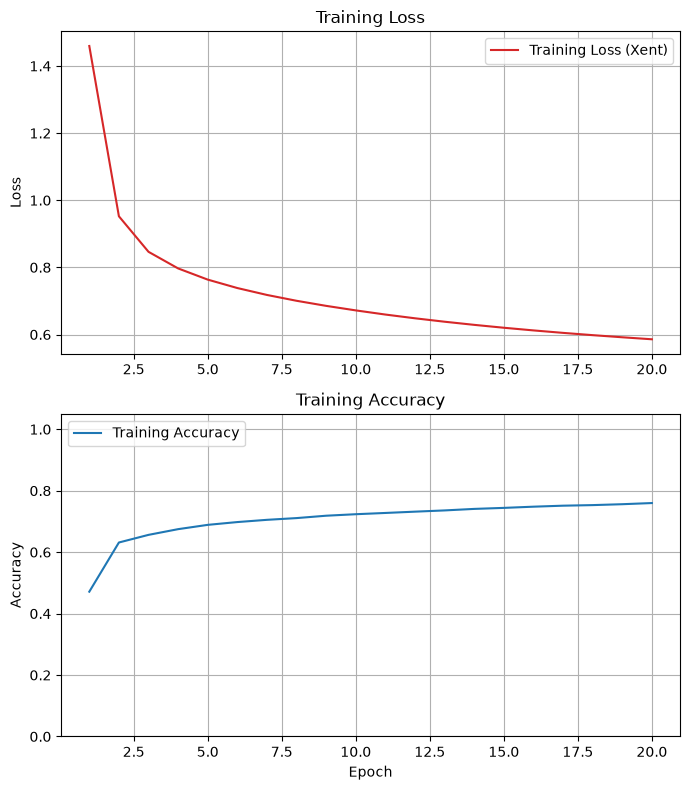

Final Training Loss:     0.5858
Final Training Accuracy: 0.7598

Training with batch size: 16


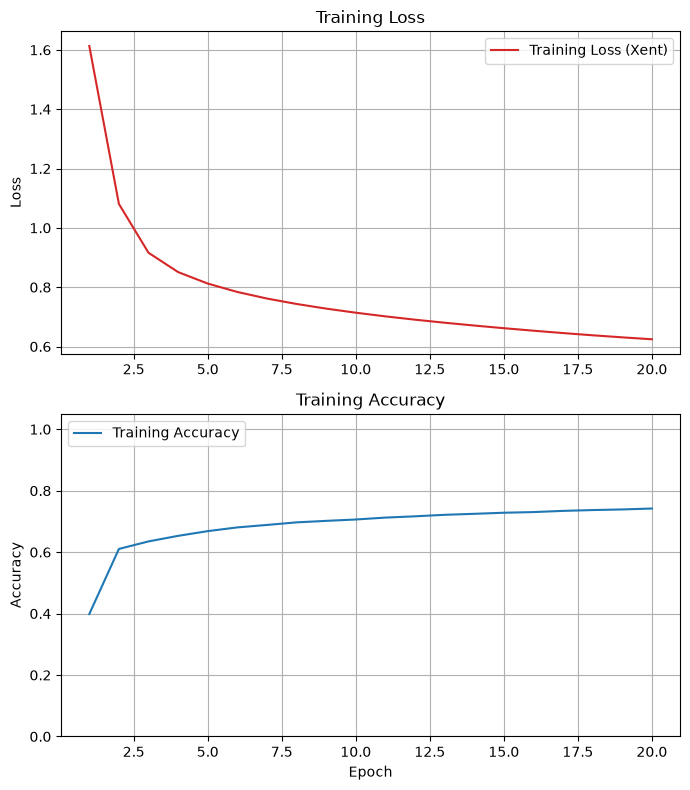

Final Training Loss:     0.6245
Final Training Accuracy: 0.7419

Training with batch size: 128


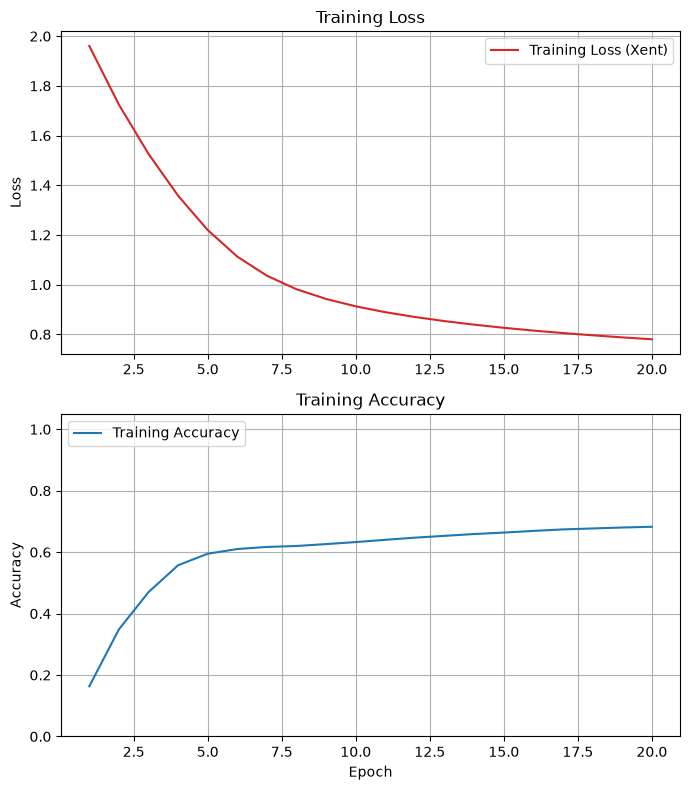

Final Training Loss:     0.7802
Final Training Accuracy: 0.6826


In [8]:
# Your code here
batch_sizes = [4, 8, 16, 128]

batch_histories = {}
batch_final_accuracies = {}

for batch_size in batch_sizes:
    print(f"\n{'=' * 50}")
    print(f"Training with batch size: {batch_size}")
    print(f"{'=' * 50}")

    # Start each experiment with a fresh model
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(random_seed)

    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(7, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=batch_size,
        verbose=0
    )

    batch_histories[batch_size] = history
    batch_final_accuracies[batch_size] = history.history["accuracy"][-1]

    plot_history(history)

In [9]:
batch_results = pd.DataFrame({
    "Batch Size": batch_final_accuracies.keys(),
    "Final Accuracy": batch_final_accuracies.values()
}).sort_values("Final Accuracy", ascending=False)

batch_results

,Batch Size,Final Accuracy
0,4,0.771826
1,8,0.759800
2,16,0.741923
3,128,0.682572


In [10]:
best_batch_size = max(
    batch_final_accuracies,
    key=batch_final_accuracies.get
)

best_batch_accuracy = batch_final_accuracies[best_batch_size]

print(f"Best batch size: {best_batch_size}")
print(f"Best final accuracy: {best_batch_accuracy:.4f}")

Best batch size: 4
Best final accuracy: 0.7718


In [11]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20

a2a = best_batch_size             # Replace 0 with your answer

In [12]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

a2a = 4


In [13]:
# Set a2b to the best accuracy score found

a2b = best_batch_accuracy             # Replace 0.0 with your answer

In [14]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7718


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.



Training with learning rate: 0.001


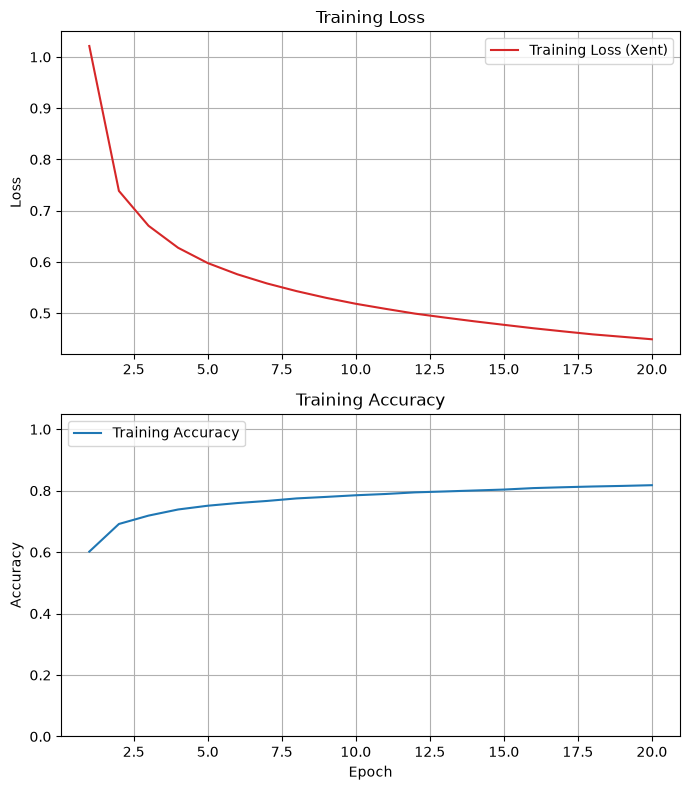

Final Training Loss:     0.4490
Final Training Accuracy: 0.8179

Training with learning rate: 0.0005


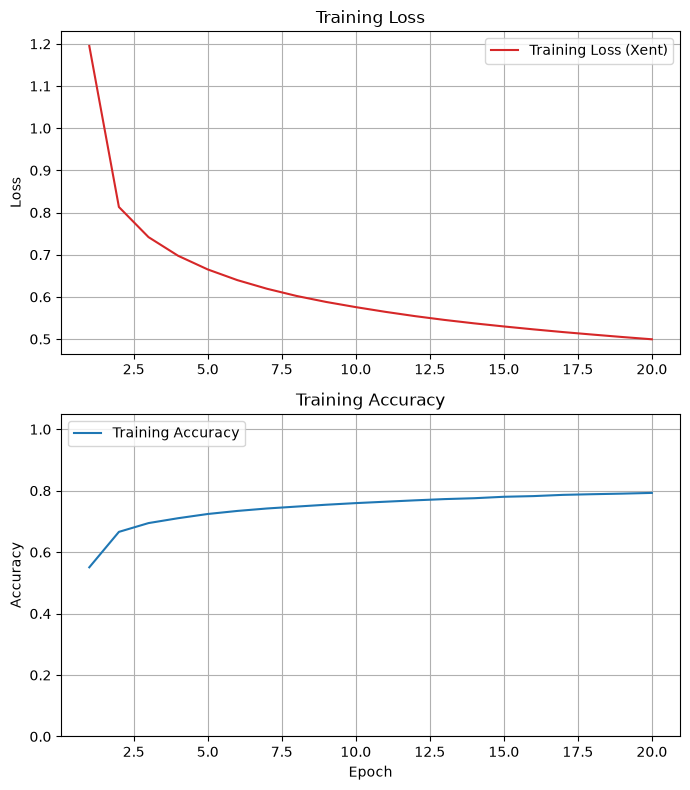

Final Training Loss:     0.4995
Final Training Accuracy: 0.7928

Training with learning rate: 0.0001


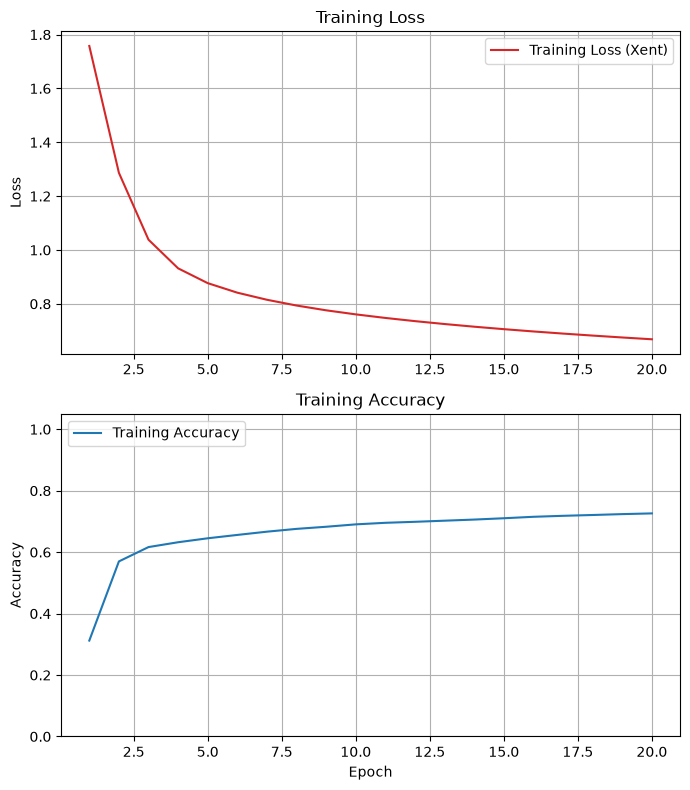

Final Training Loss:     0.6684
Final Training Accuracy: 0.7261

Training with learning rate: 5e-05


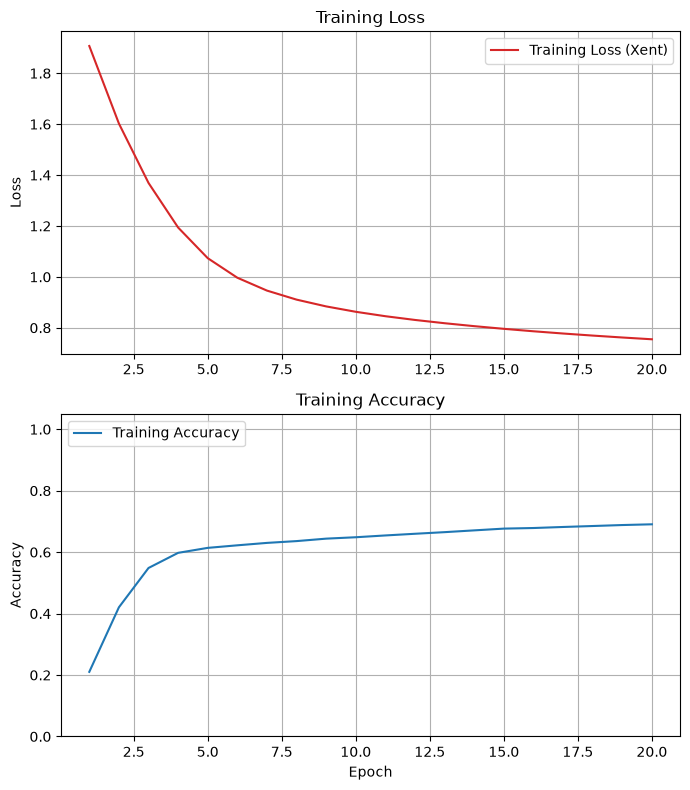

Final Training Loss:     0.7549
Final Training Accuracy: 0.6906

Training with learning rate: 1e-05


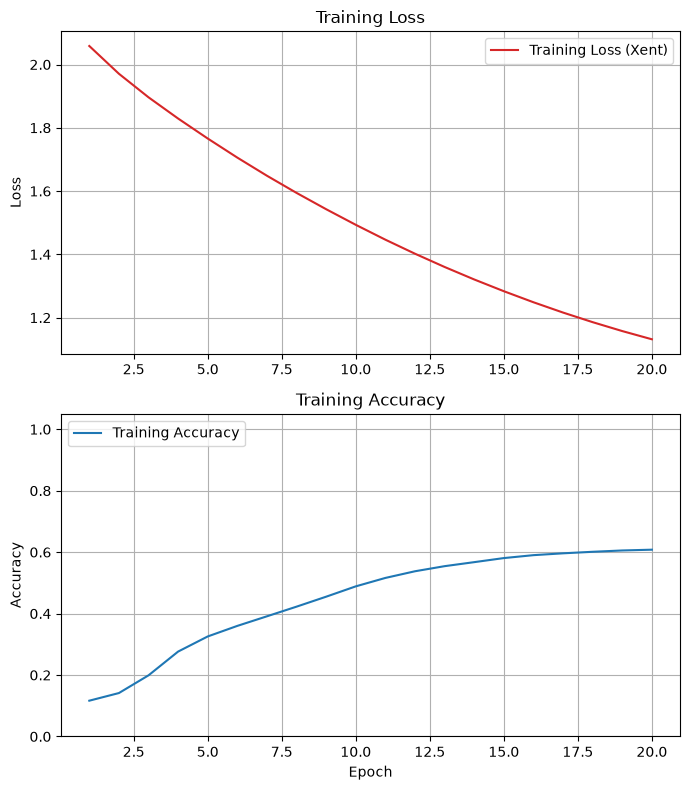

Final Training Loss:     1.1317
Final Training Accuracy: 0.6080


In [15]:
# Your code here

learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

lr_histories = {}
lr_final_accuracies = {}

for learning_rate in learning_rates:
    print(f"\n{'=' * 50}")
    print(f"Training with learning rate: {learning_rate}")
    print(f"{'=' * 50}")

    # Build a fresh model for every experiment
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(random_seed)

    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(7, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    lr_histories[learning_rate] = history
    lr_final_accuracies[learning_rate] = history.history["accuracy"][-1]

    plot_history(history)

In [16]:
lr_results = pd.DataFrame({
    "Learning Rate": lr_final_accuracies.keys(),
    "Final Accuracy": lr_final_accuracies.values()
}).sort_values("Final Accuracy", ascending=False)

lr_results

,Learning Rate,Final Accuracy
0,0.00100,0.817916
1,0.00050,0.792823
2,0.00010,0.726126
3,0.00005,0.690633
4,0.00001,0.608009


In [17]:
best_learning_rate = max(
    lr_final_accuracies,
    key=lr_final_accuracies.get
)

best_lr_accuracy = lr_final_accuracies[best_learning_rate]

print(f"Best learning rate: {best_learning_rate}")
print(f"Best final accuracy: {best_lr_accuracy:.4f}")

Best learning rate: 0.001
Best final accuracy: 0.8179


In [18]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = best_learning_rate             # Replace 0.0 with your answer

In [19]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0010


In [20]:
# Set a3b to the accuracy found by the best learning rate

a3b = best_lr_accuracy            # Replace 0.0 with your answer

In [21]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.8179


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.

Steps per epoch: 481
Total decay steps: 9620

Cosine decay with initial learning rate: 0.01


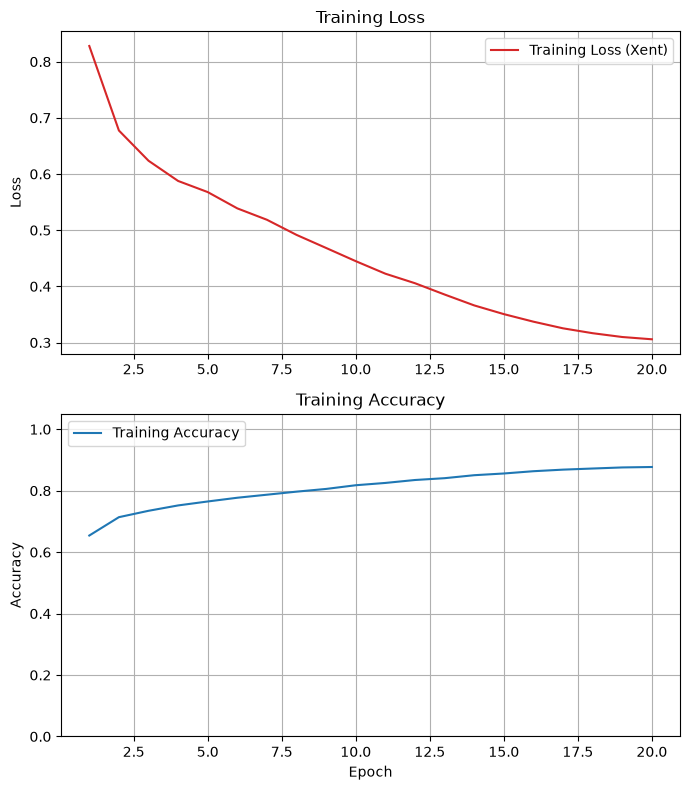

Final Training Loss:     0.3058
Final Training Accuracy: 0.8771

Cosine decay with initial learning rate: 0.005


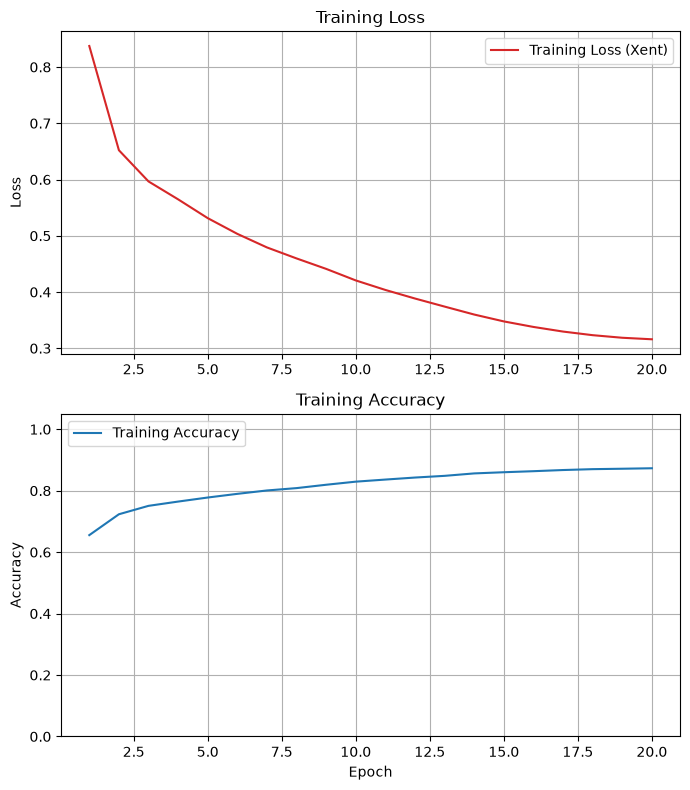

Final Training Loss:     0.3160
Final Training Accuracy: 0.8730

Cosine decay with initial learning rate: 0.001


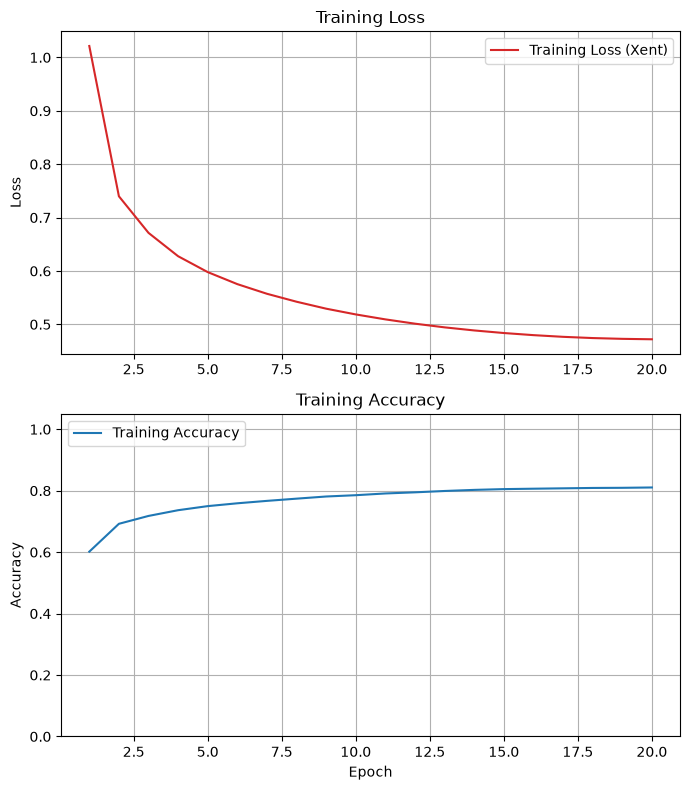

Final Training Loss:     0.4721
Final Training Accuracy: 0.8105

Cosine decay with initial learning rate: 0.0005


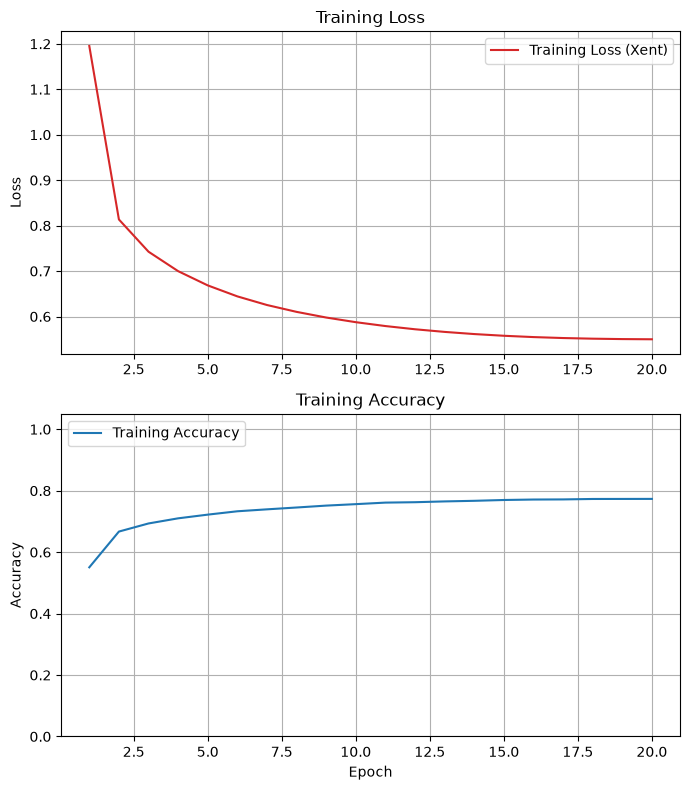

Final Training Loss:     0.5499
Final Training Accuracy: 0.7733

Cosine decay with initial learning rate: 0.0001


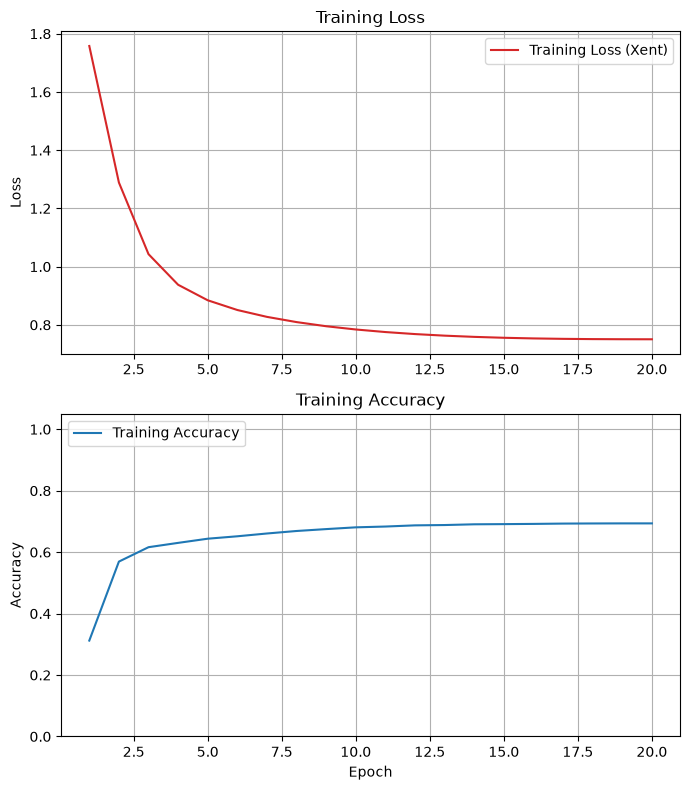

Final Training Loss:     0.7505
Final Training Accuracy: 0.6936


In [22]:
# Your code here

initial_learning_rates = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]

epochs = 20
batch_size = 32

# CosineDecay updates after every batch
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total decay steps: {total_steps}")

cosine_histories = {}
cosine_final_accuracies = {}

for initial_lr in initial_learning_rates:
    print(f"\n{'=' * 55}")
    print(f"Cosine decay with initial learning rate: {initial_lr}")
    print(f"{'=' * 55}")

    # Build a fresh model for each experiment
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(random_seed)

    # Create the cosine-decay schedule
    lr_schedule = CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=total_steps,
        alpha=0.0
    )

    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(7, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    cosine_histories[initial_lr] = history
    cosine_final_accuracies[initial_lr] = history.history["accuracy"][-1]

    plot_history(history)

In [23]:
cosine_results = pd.DataFrame({
    "Initial Learning Rate": cosine_final_accuracies.keys(),
    "Final Accuracy": cosine_final_accuracies.values()
}).sort_values("Final Accuracy", ascending=False)

cosine_results

,Initial Learning Rate,Final Accuracy
0,0.0100,0.877137
1,0.0050,0.873042
2,0.0010,0.810505
3,0.0005,0.773321
4,0.0001,0.693623


In [24]:
best_cosine_lr = max(
    cosine_final_accuracies,
    key=cosine_final_accuracies.get
)

best_cosine_accuracy = cosine_final_accuracies[best_cosine_lr]

print(f"Best initial learning rate: {best_cosine_lr}")
print(f"Best final accuracy: {best_cosine_accuracy:.4f}")

Best initial learning rate: 0.01
Best final accuracy: 0.8771


In [26]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = best_cosine_lr            # Replace 0.0 with your answer

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.0100


In [28]:
# Set a4b to the best accuracy found

a4b = best_cosine_accuracy             # Replace 0.0 with your answer

In [29]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8771


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

In [32]:
# Your code here -- add as many cells as you need

batch_sizes = [8, 16, 32, 64]
initial_learning_rates = [0.005, 0.0075, 0.01, 0.015]
epochs = 20

tuning_results = []

for batch_size in batch_sizes:
    for initial_lr in initial_learning_rates:
        print(
            f"Training: batch_size={batch_size}, "
            f"initial_lr={initial_lr}"
        )

        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(random_seed)

        steps_per_epoch = int(
            np.ceil(len(X_train) / batch_size)
        )
        total_steps = epochs * steps_per_epoch

        lr_schedule = CosineDecay(
            initial_learning_rate=initial_lr,
            decay_steps=total_steps,
            alpha=0.0
        )

        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(64, activation="relu"),
            Dense(32, activation="relu"),
            Dense(7, activation="softmax")
        ])

        model.compile(
            optimizer=Adam(learning_rate=lr_schedule),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        final_accuracy = history.history["accuracy"][-1]
        final_loss = history.history["loss"][-1]

        tuning_results.append({
            "batch_size": batch_size,
            "initial_lr": initial_lr,
            "final_accuracy": final_accuracy,
            "final_loss": final_loss
        })

        print(f"Final accuracy: {final_accuracy:.4f}")

Training: batch_size=8, initial_lr=0.005
Final accuracy: 0.8882
Training: batch_size=8, initial_lr=0.0075
Final accuracy: 0.8766
Training: batch_size=8, initial_lr=0.01
Final accuracy: 0.8643
Training: batch_size=8, initial_lr=0.015
Final accuracy: 0.8329
Training: batch_size=16, initial_lr=0.005
Final accuracy: 0.8825
Training: batch_size=16, initial_lr=0.0075
Final accuracy: 0.8883
Training: batch_size=16, initial_lr=0.01
Final accuracy: 0.8767
Training: batch_size=16, initial_lr=0.015
Final accuracy: 0.8491
Training: batch_size=32, initial_lr=0.005
Final accuracy: 0.8730
Training: batch_size=32, initial_lr=0.0075
Final accuracy: 0.8862
Training: batch_size=32, initial_lr=0.01
Final accuracy: 0.8771
Training: batch_size=32, initial_lr=0.015
Final accuracy: 0.8658
Training: batch_size=64, initial_lr=0.005
Final accuracy: 0.8597
Training: batch_size=64, initial_lr=0.0075
Final accuracy: 0.8705
Training: batch_size=64, initial_lr=0.01
Final accuracy: 0.8767
Training: batch_size=64, init

In [33]:
tuning_df = pd.DataFrame(tuning_results)

tuning_df = tuning_df.sort_values(
    by=["final_accuracy", "final_loss"],
    ascending=[False, True]
).reset_index(drop=True)

tuning_df

,batch_size,initial_lr,final_accuracy,final_loss
0,16,0.0075,0.888253,0.288559
1,8,0.0050,0.888188,0.285682
2,32,0.0075,0.886238,0.288787
3,16,0.0050,0.882468,0.295174
4,64,0.0150,0.878502,0.297778
5,32,0.0100,0.877137,0.305834
6,16,0.0100,0.876747,0.312897
7,64,0.0100,0.876682,0.315772
8,8,0.0075,0.876552,0.304890
9,32,0.0050,0.873042,0.316029


In [36]:
best_batch_size = int(tuning_df.loc[0, "batch_size"])
best_initial_lr = float(tuning_df.loc[0, "initial_lr"])
best_tuning_accuracy = float(tuning_df.loc[0, "final_accuracy"])

print(f"Best batch size: {best_batch_size}")
print(f"Best initial learning rate: {best_initial_lr}")
print(f"Best training accuracy: {best_tuning_accuracy:.4f}")

Best batch size: 16
Best initial learning rate: 0.0075
Best training accuracy: 0.8883


Epoch 1/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6580 - loss: 0.8231
Epoch 2/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7164 - loss: 0.6790
Epoch 3/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7363 - loss: 0.6334
Epoch 4/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7484 - loss: 0.6030
Epoch 5/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7668 - loss: 0.5645
Epoch 6/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7759 - loss: 0.5390
Epoch 7/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7889 - loss: 0.5149
Epoch 8/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8012 - loss: 0.4820
Epoch 9/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8127 - loss: 0.4602
Epoch 10/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8229 - loss: 0.4349
Epoch 11/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8318 - loss: 0.4173
Epoch 12/20
962/962 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

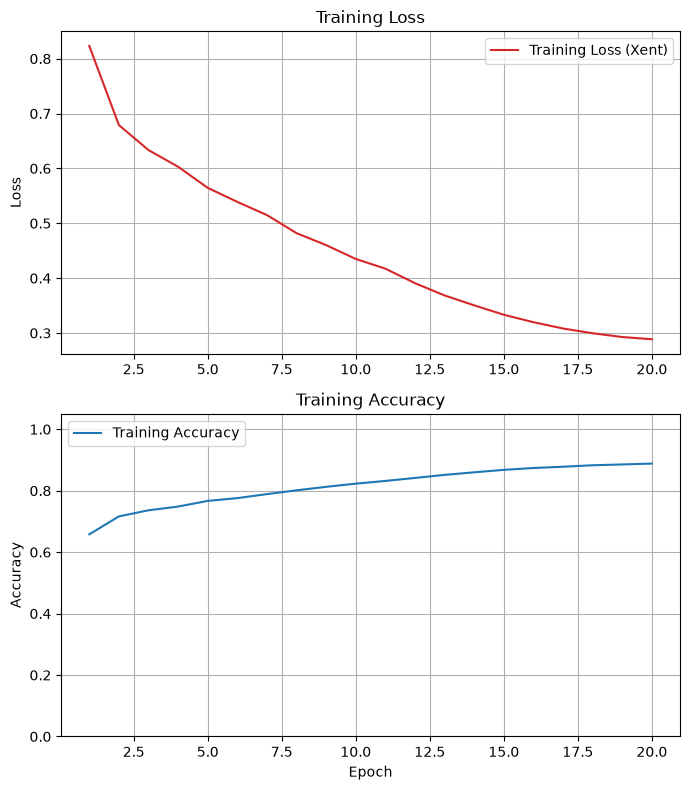

Final Training Loss:     0.2886
Final Training Accuracy: 0.8883


In [37]:
epochs = 20

# Recalculate cosine-decay steps using the best batch size
steps_per_epoch = int(
    np.ceil(len(X_train) / best_batch_size)
)
total_steps = epochs * steps_per_epoch

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(random_seed)

best_lr_schedule = CosineDecay(
    initial_learning_rate=best_initial_lr,
    decay_steps=total_steps,
    alpha=0.0
)

# Keep the required architecture unchanged
best_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(7, activation="softmax")
])

best_model.compile(
    optimizer=Adam(learning_rate=best_lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Retrain using the selected configuration
best_history = best_model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=best_batch_size,
    verbose=1
)

plot_history(best_history)

In [38]:
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

final_training_accuracy = best_history.history["accuracy"][-1]

print(f"Best batch size:        {best_batch_size}")
print(f"Best initial LR:        {best_initial_lr}")
print(f"Final training loss:    {best_history.history['loss'][-1]:.4f}")
print(f"Final training accuracy:{final_training_accuracy:.4f}")
print(f"Test loss:              {test_loss:.4f}")
print(f"Test accuracy:          {test_accuracy:.4f}")

Best batch size:        16
Best initial LR:        0.0075
Final training loss:    0.2886
Final training accuracy:0.8883
Test loss:              0.4300
Test accuracy:          0.8427


In [39]:
# Set a5a to the best training accuracy found by your best model

a5a = final_training_accuracy            # Replace 0.0 with your answer

In [40]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.8883


In [41]:
# Set a5b to the test accuracy found by your best model

a5b = test_accuracy             # Replace 0.0 with your answer

In [42]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8427


## Reflection Questions (ungraded)

1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

3. **More epochs, same LR.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc? 

4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


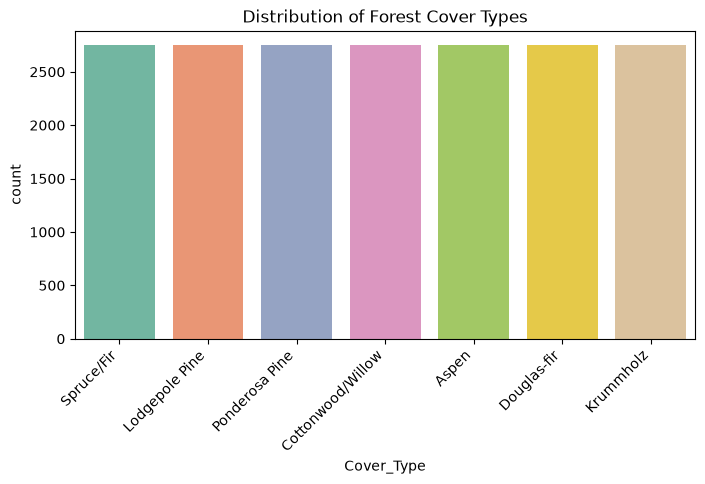

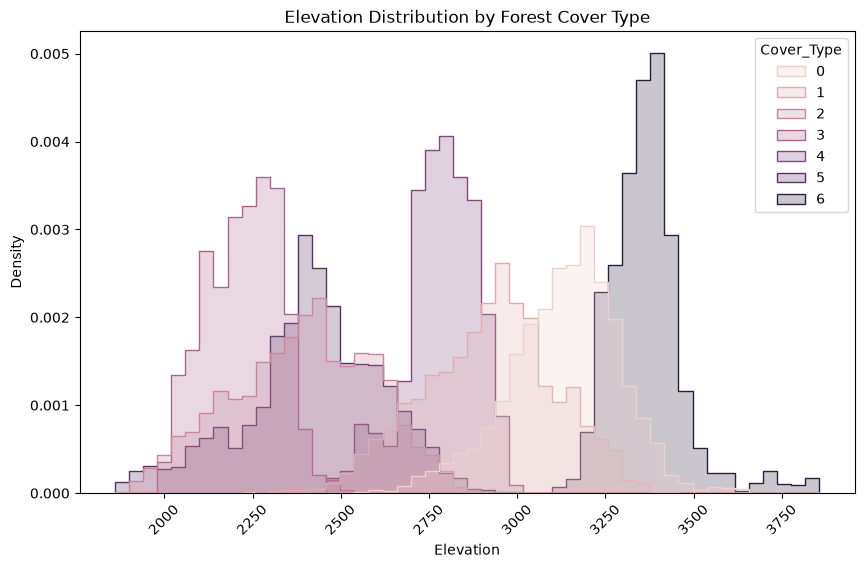

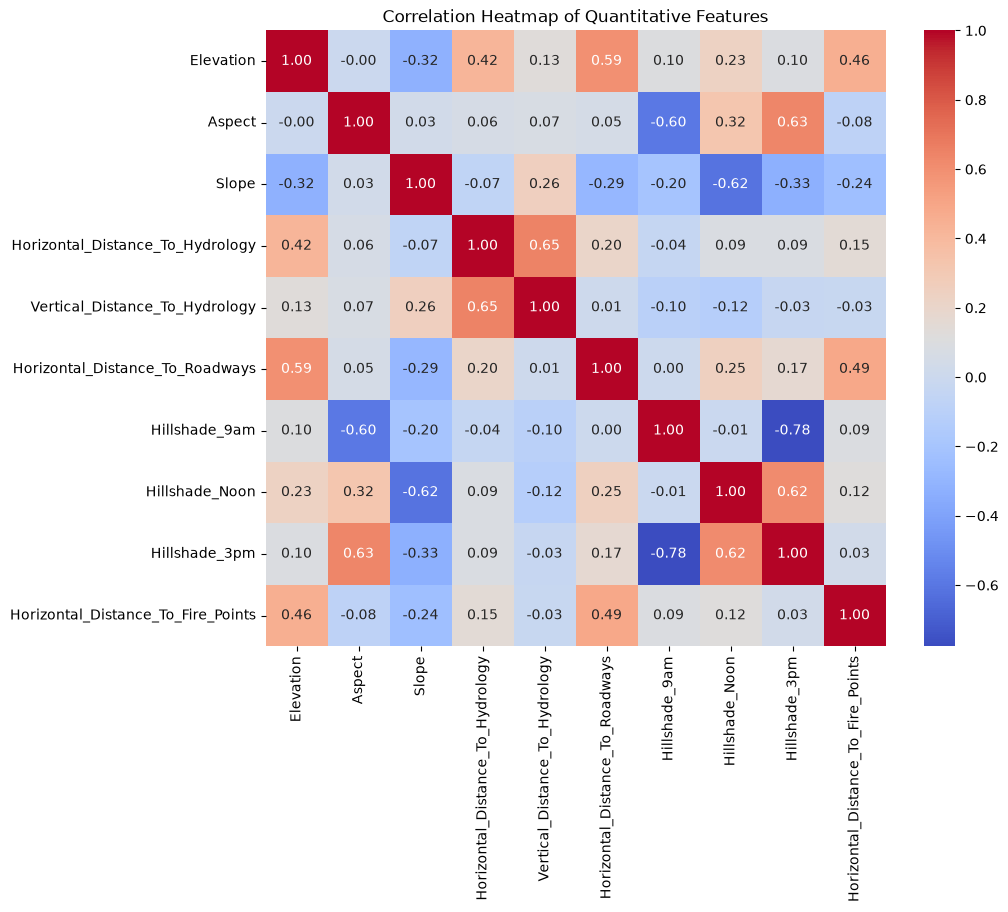

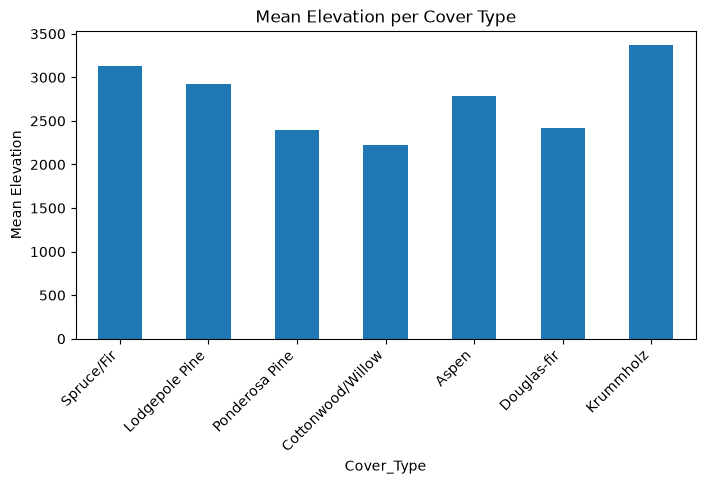

In [43]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()
